In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/bag-of-words-meets-bags-of-popcorn-/testData.tsv
/kaggle/input/bag-of-words-meets-bags-of-popcorn-/labeledTrainData.tsv
/kaggle/input/bag-of-words-meets-bags-of-popcorn-/sampleSubmission.csv
/kaggle/input/bag-of-words-meets-bags-of-popcorn-/unlabeledTrainData.tsv


In [2]:
train=pd.read_csv("/kaggle/input/bag-of-words-meets-bags-of-popcorn-/labeledTrainData.tsv",delimiter="\t")
train.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


In [3]:
# Sample Review
train["review"][20]

'\\Soylent Green\\" is one of the best and most disturbing science fiction movies of the 70\'s and still very persuasive even by today\'s standards. Although flawed and a little dated, the apocalyptic touch and the environmental premise (typical for that time) still feel very unsettling and thought-provoking. This film\'s quality-level surpasses the majority of contemporary SF flicks because of its strong cast and some intense sequences that I personally consider classic. The New York of 2022 is a depressing place to be alive, with over-population, unemployment, an unhealthy climate and the total scarcity of every vital food product. The only form of food available is synthetic and distributed by the Soylent company. Charlton Heston (in a great shape) plays a cop investigating the murder of one of Soylent\'s most eminent executives and he stumbles upon scandals and dark secrets... The script is a little over-sentimental at times and the climax doesn\'t really come as a big surprise, st

# Text Preprocessing

In [4]:
!pip install nltk
!pip install beautifulsoup4

In [5]:
import re
import nltk
from bs4 import BeautifulSoup

In [6]:
nltk.download("all")


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /usr/share/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /usr/share/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /usr/share/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron

True

In [7]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [8]:
stopwords=stopwords.words("english")
wordnet_lemma=WordNetLemmatizer()

In [9]:
review = train['review'][0]

In [10]:
review

"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when it finally sta

In [22]:
def preprocess_text(review):
    # Remove all HTML tags
    review= BeautifulSoup(review).get_text()
    
    # Remove anything which is not a character
    review=re.sub("[^a-zA-Z]"," ",review)
    
    #Lowercase
    review=review.lower()
    
    # Stopword
    review = " ".join([i for i in review.split() if i not in stopwords])
    
    
    # Lemmatizer
    review = " ".join([wordnet_lemma.lemmatize(i) for i in review.split()])

    return review

In [23]:
review=review = train['review'][0]
print("Original Text: ")
print(review)
print("_"*25)
cleaned_review= preprocess_text(review)
print("Cleaner Text: ")
print(cleaned_review)

Original Text: 
With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent. Moonwalker is part biography, part feature film which i remember going to see at the cinema when it was originally released. Some of it has subtle messages about MJ's feeling towards the press and also the obvious message of drugs are bad m'kay.<br /><br />Visually impressive but of course this is all about Michael Jackson so unless you remotely like MJ in anyway then you are going to hate this and find it boring. Some may call MJ an egotist for consenting to the making of this movie BUT MJ and most of his fans would say that he made it for the fans which if true is really nice of him.<br /><br />The actual feature film bit when

In [26]:
# Apply this function over full dataframe

train['clean_review']=train['review'].apply(preprocess_text)

[('film', 25304),
 ('movie', 19075),
 ('one', 13653),
 ('see', 10907),
 ('make', 10789),

# EDA
## Find out most common words and then Visualize it as well
### For both positive and negative review

In [27]:
# Give me list of all words frequency
train.head()

,id,sentiment,review,clean_review
0,5814_8,1,With all this stuff going down at the moment w...,stuff going moment mj started listening music ...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi...",classic war world timothy hines entertaining f...
2,7759_3,0,The film starts with a manager (Nicholas Bell)...,film start manager nicholas bell giving welcom...
3,3630_4,0,It must be assumed that those who praised this...,must assumed praised film greatest filmed oper...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...,superbly trashy wondrously unpretentious explo...


In [33]:
freq_list={}
for review in train['clean_review'].tolist():
    for word in review.split():
        freq_list[word]=freq_list.get(word,0)+1

In [40]:
# Give 10 most frequent words

# Sort freq_list dictionary
sorted_freq_words=dict(sorted(freq_list.items(), key= lambda item:item[1], reverse=True))

In [76]:
from collections import Counter
cnt = Counter(" ".join(train['clean_review'].tolist()).split())


In [80]:
# Most frequent words in Positive as well as negative reviews

In [82]:
pos_cnt = Counter(" ".join(train.loc[train['sentiment']==1]['clean_review'].tolist()).split())
neg_cnt = Counter(" ".join(train.loc[train['sentiment']==0]['clean_review'].tolist()).split())

In [83]:
pos_cnt.most_common(10)

[('film', 24745),
 ('movie', 22657),
 ('one', 14169),
 ('like', 9270),
 ('time', 8346),
 ('good', 7762),
 ('story', 7478),
 ('character', 7073),
 ('well', 6488),
 ('great', 6435)]

In [84]:
neg_cnt.most_common(10)

[('movie', 29037),
 ('film', 22289),
 ('one', 13572),
 ('like', 11470),
 ('even', 7684),
 ('time', 7613),
 ('good', 7435),
 ('bad', 7394),
 ('character', 7104),
 ('would', 7036)]

In [89]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(stopwords=["film","movie"],width=800, height=400, background_color='white').generate(" ".join(train['clean_review'].tolist()))

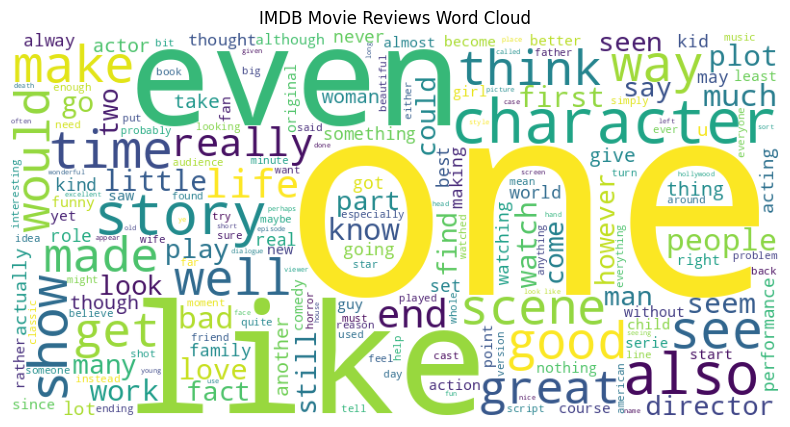

In [90]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')  
plt.title("IMDB Movie Reviews Word Cloud")
plt.show()

In [91]:
!wget http://www.stencilry.org/stencils/movies/alice%20in%20wonderland/255fk.jpg

--2026-02-20 16:33:35--  http://www.stencilry.org/stencils/movies/alice%20in%20wonderland/255fk.jpg
Resolving www.stencilry.org (www.stencilry.org)... 3.33.251.168, 15.197.225.128
Connecting to www.stencilry.org (www.stencilry.org)|3.33.251.168|:80... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-02-20 16:33:35 ERROR 404: Not Found.



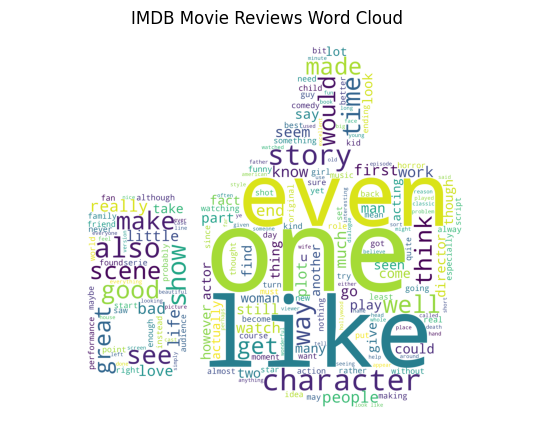

In [95]:
from PIL import Image
upvote_mask = np.array(Image.open("/kaggle/input/datasets/aayushkubba/mask-image/upvote.png"))

wordcloud = WordCloud(stopwords=["film","movie"],width=800, height=400, mask=upvote_mask,background_color='white').generate(" ".join(train['clean_review'].tolist()))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')  
plt.title("IMDB Movie Reviews Word Cloud")
plt.show()


# BOW Model

In [96]:
from sklearn.feature_extraction.text import CountVectorizer


In [97]:
train.columns

Index(['id', 'sentiment', 'review', 'clean_review'], dtype='object')

In [98]:
X=train['clean_review']
y=train['sentiment']

In [99]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [100]:
def create_vector(vectorizer,data):
    '''Pass vectorizer and data'''
    train_vector=vectorizer.transform(data.tolist())
    return train_vector.toarray()

In [101]:
len(cnt)

66507

In [135]:
vectorizer=CountVectorizer(max_features=1000)

In [136]:
vectorizer.fit(X_train.tolist())

CountVectorizer(max_features=1000)

In [137]:
X_train_vector=create_vector(vectorizer,X_train)
X_test_vector=create_vector(vectorizer,X_test)

In [138]:
X_train_vector.shape

(16750, 1000)

In [139]:
X_train_vector[100]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,

In [140]:
X_train[0]

'stuff going moment mj started listening music watching odd documentary watched wiz watched moonwalker maybe want get certain insight guy thought really cool eighty maybe make mind whether guilty innocent moonwalker part biography part feature film remember going see cinema originally released subtle message mj feeling towards press also obvious message drug bad kay visually impressive course michael jackson unless remotely like mj anyway going hate find boring may call mj egotist consenting making movie mj fan would say made fan true really nice actual feature film bit finally start minute excluding smooth criminal sequence joe pesci convincing psychopathic powerful drug lord want mj dead bad beyond mj overheard plan nah joe pesci character ranted wanted people know supplying drug etc dunno maybe hate mj music lot cool thing like mj turning car robot whole speed demon sequence also director must patience saint came filming kiddy bad sequence usually director hate working one kid let a

In [141]:
# Create a classifier
# Classical ML
# RF classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
forest=RandomForestClassifier()
forest.fit(X_train_vector,y_train)


y_pred=forest.predict(X_test_vector)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.83      0.82      4105
           1       0.83      0.82      0.82      4145

    accuracy                           0.82      8250
   macro avg       0.82      0.82      0.82      8250
weighted avg       0.82      0.82      0.82      8250



In [143]:
len(vectorizer.vocabulary_)

1000

In [144]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf_vectorizer = TfidfVectorizer(analyzer="word", tokenizer=nltk.word_tokenize,
    preprocessor=None, stop_words='english', max_features=2000)
tf_vectorizer.fit(X_train.tolist())

X_train_tfvector=create_vector(tf_vectorizer,X_train)
X_test_tfvector=create_vector(tf_vectorizer,X_test)

X_test_tfvector.shape, X_train_tfvector.shape

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


((8250, 2000), (16750, 2000))

In [145]:
forest=RandomForestClassifier()
forest.fit(X_train_tfvector,y_train)


y_pred=forest.predict(X_test_tfvector)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83      4105
           1       0.84      0.82      0.83      4145

    accuracy                           0.83      8250
   macro avg       0.83      0.83      0.83      8250
weighted avg       0.83      0.83      0.83      8250



In [146]:
# Deep lEarning -> LSTMS
from keras.layers import Dense, Dropout, SimpleRNN
from keras.models import Sequential

2026-02-20 16:57:50.202209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771606670.517965      56 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771606670.606652      56 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771606671.387258      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771606671.387301      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771606671.387304      56 computation_placer.cc:177] computation placer alr

In [147]:
# Lets create a simple ANN model
model_rnn=Sequential()
model_rnn.add(SimpleRNN(units=16,activation='relu', input_shape=(2000,1)))
# model_rnn.add(Dense(units=32, activation='relu'))
# model_rnn.add(Dense(units=64, activation='relu'))
model_rnn.add(Dense(units=1)) # Sigmoid
model_rnn.summary()

2026-02-20 16:58:18.030129: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_cross_entropy', metrics=['accuracy'])
history=model.fit(X_train,y_train, epochs=10, validation_data=(X_test,y_test))

In [ ]:
# Home word -> Try converting text to number using word2vec
# 